Install Packages and Import Libraries

In [1]:
# %pip install -q -r ../requirements.txt

In [2]:
# Import required libraries for BUSSAM training and evaluation.
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
from IPython.display import display

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

from src.local.localization.helpers import (
    download_bussam_code,
    download_sam_vit_b_checkpoint,
    find_best_bussam_checkpoint,
    find_bussam_repo,
    prepare_busi_for_bussam,
    set_bussam_test_gpu,
    set_bussam_test_settings,
    set_bussam_training_settings,
    test_bussam_on_busi,
    train_bussam_on_busi
)

Check GPU Availability

In [3]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device -', device)

if device == 'cuda':
    print(torch.cuda.get_device_name(0))

device - cuda
NVIDIA GeForce RTX 5060 Laptop GPU


Prepare BUSSAM Assets

In [ ]:
'''
We use BUSSAM as a breast ultrasound lesion segmentation framework to generate lesion masks for the localisation stage of the project.
Training is restricted to benign and malignant BUSI cases because normal scans do not contain lesion masks and therefore cannot provide pixel-level supervision for lesion segmentation. 
In the final demonstration, only scans classified as benign or malignant by the VLM will be passed to the trained BUSSAM for lesion localisation.
See: https://github.com/bscs12/BUSSAM
'''

# Clone the BUSSAM repository.
bussam_root = download_bussam_code()

# Download the SAM ViT-B initialization checkpoint.
sam_checkpoint = download_sam_vit_b_checkpoint()

clone: exists = False path = C:\Users\mason\Desktop\busi-vlm-project\external\BUSSAM
sam checkpoint: exists = False path = C:\Users\mason\Desktop\busi-vlm-project\external\BUSSAM\checkpoints\sam_vit_b_01ec64.pth


Prepare the BUSI Dataset in BUSSAM Format

In [9]:
# Convert the existing BUSI train/val/test split into BUSSAM's expected folder layout.
# Note: BUSSAM expects the BUSI dataset to contain paired ultrasound images and lesion masks as well as train/validation/test split files.
dataset_info = prepare_busi_for_bussam()
dataset_info

dataset source = C:\Users\mason\Desktop\busi-vlm-project\dataset\split
dataset classes = ['benign', 'malignant']
train/val/test = 371/79/80
files copied for BUSSAM.


{'img_dir': WindowsPath('C:/Users/mason/Desktop/busi-vlm-project/external/BUSSAM/datasets/BUSI/img'),
 'label_dir': WindowsPath('C:/Users/mason/Desktop/busi-vlm-project/external/BUSSAM/datasets/BUSI/label'),
 'split_files': {'train': WindowsPath('C:/Users/mason/Desktop/busi-vlm-project/external/BUSSAM/datasets/MainPatient/BUSI_train.txt'),
  'val': WindowsPath('C:/Users/mason/Desktop/busi-vlm-project/external/BUSSAM/datasets/MainPatient/BUSI_val.txt'),
  'test': WindowsPath('C:/Users/mason/Desktop/busi-vlm-project/external/BUSSAM/datasets/MainPatient/BUSI_test.txt')},
 'counts': {'train': 371, 'val': 79, 'test': 80}}

Train BUSSAM

In [10]:
# Training settings.
epochs = 20
batch_size = 8
learning_rate = 0.0005

set_bussam_training_settings(epochs = epochs, output_dir = 'outputs/')

# Train BUSSAM on the prepared benign and malignant BUSI images and masks.
train_results = train_bussam_on_busi(batch_size = batch_size, base_lr = learning_rate)

# Store training results for plotting the curves.
history = train_results['history']

# Get the best checkpoint (with the highest Dice score).
best_checkpoint = train_results['best_checkpoint'] or find_best_bussam_checkpoint()
best_checkpoint = Path(best_checkpoint)

# Set BUSSAM to use this checkpoint for test evaluation.
set_bussam_test_settings(best_checkpoint, device = device, visual = True)
print('best BUSSAM checkpoint:', best_checkpoint, '- exists:', best_checkpoint.exists())

config: epochs=20 output=outputs/
BUSSAM repo imports patched
Total_params:25052432
-------------------------------------------------------
epoch:1/20, train_loss:0.5200
test_speed:19.3808
epoch:1/20, val_loss:0.2898, val_dice:71.55924
-------------------------------------------------------
-------------------------------------------------------
epoch:2/20, train_loss:0.3036
test_speed:14.8091
epoch:2/20, val_loss:0.2593, val_dice:73.61607
-------------------------------------------------------
-------------------------------------------------------
epoch:3/20, train_loss:0.2832
test_speed:14.7838
epoch:3/20, val_loss:0.2289, val_dice:74.36845
-------------------------------------------------------
-------------------------------------------------------
epoch:4/20, train_loss:0.2376
test_speed:14.7598
epoch:4/20, val_loss:0.2206, val_dice:75.02064
-------------------------------------------------------
-------------------------------------------------------
epoch:5/20, train_loss:0.254

Show Training Curves

,epoch,val_loss,val_dice,train_loss
15,16,0.1406,80.74028,0.1717
16,17,0.1403,82.55781,0.1886
17,18,0.1583,80.52744,0.1908
18,19,0.1385,82.10647,0.1683
19,20,0.1351,81.94050,0.1601


Saved BUSSAM training history: c:\Users\mason\Desktop\busi-vlm-project\results\localization\bussam_training_history.csv


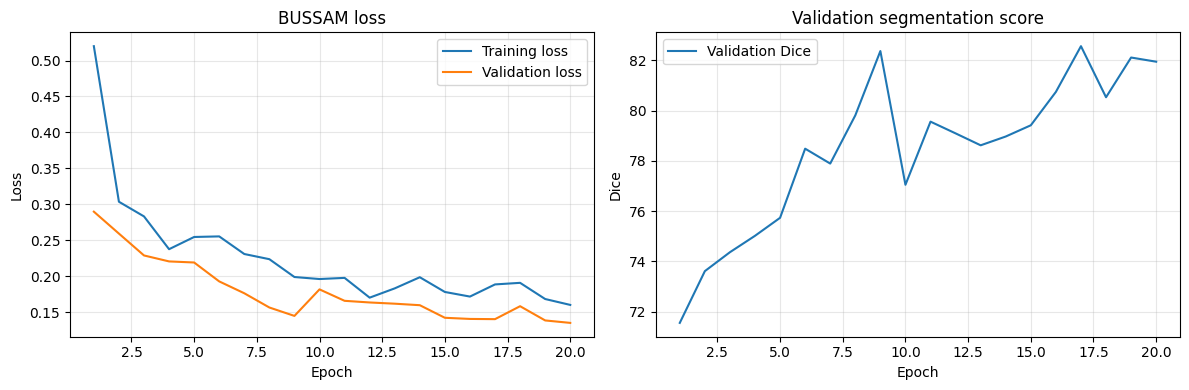

In [11]:
# Plot the training loss and validation Dice recorded by BUSSAM training.
history_dataframe = pd.DataFrame(history)

history_dataframe['train_loss'] = pd.to_numeric(history_dataframe['train_loss'], errors='coerce')
history_dataframe['val_loss'] = pd.to_numeric(history_dataframe['val_loss'], errors='coerce')
history_dataframe['val_dice'] = pd.to_numeric(history_dataframe['val_dice'], errors='coerce')

history_path = project_root / 'results'/'localization'/'bussam_training_history.csv'
history_path.parent.mkdir(parents=True, exist_ok=True)
history_dataframe.to_csv(history_path, index=False)

display(history_dataframe.tail())
print('Saved BUSSAM training history:', history_path)

figure, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_dataframe['epoch'], history_dataframe['train_loss'], label='Training loss')
axes[0].plot(history_dataframe['epoch'], history_dataframe['val_loss'], label='Validation loss')
axes[0].set_title('BUSSAM loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history_dataframe['epoch'], history_dataframe['val_dice'], label='Validation Dice')
axes[1].set_title('Validation segmentation score')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Dice')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()
plt.close(figure)

Held-Out BUSSAM Test Evaluation

In [12]:
# BUSSAM test.py hard-codes CUDA_VISIBLE_DEVICES so I had to patch it before the test evaluation.
if device == 'cuda':
    set_bussam_test_gpu('0')
else:
    print('CPU selected.')

# Runs BUSSAM on the held-out benign and malignant test split only. The generated masks are reused by the final demo notebook.
bussam_test_result = test_bussam_on_busi(checkpoint = best_checkpoint, batch_size = batch_size, device = device)
print('BUSSAM test return code -', bussam_test_result.returncode)

BUSSAM repo imports patched
Total_params:25052432
[INFO] Register count_convNd() for <class 'torch.nn.modules.conv.Conv2d'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.container.Sequential'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.pooling.MaxPool2d'>.
[INFO] Register count_convNd() for <class 'torch.nn.modules.conv.Conv1d'>.
[INFO] Register count_normalization() for <class 'torch.nn.modules.normalization.LayerNorm'>.
[INFO] Register count_linear() for <class 'torch.nn.modules.linear.Linear'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.activation.ReLU'>.
[INFO] Register count_convNd() for <class 'torch.nn.modules.conv.ConvTranspose2d'>.
Gflops:105.865623552, params:91869412.0
test_speed:19.3214
model_name:BUSSAM, task:BUSI, checkpoint:C:/Users/mason/Desktop/busi-vlm-project/external/BUSSAM/outputs/BUSSAM_0529182224/checkpoints/BUSSAM_05292206_17_82.55780690870242.pth
mean_acc:96.34287, mean_se:86.17744, mean_dice:79.24468, mean_iou:69.09310, me

Preview Held-Out BUSSAM Masks

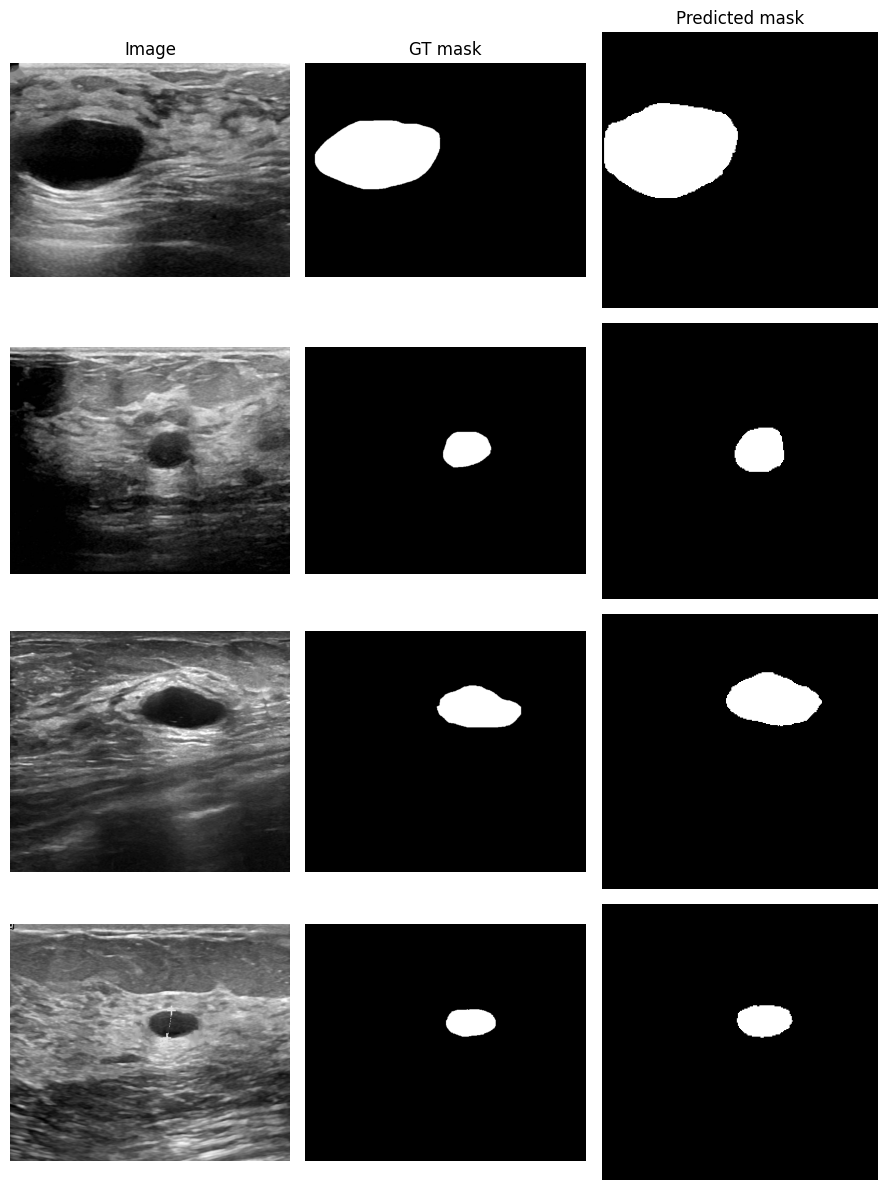

In [13]:
# Show 4 held-out examples with the original image, ground-truth mask, and BUSSAM predicted mask.
bussam_root = find_bussam_repo()
prediction_dir = bussam_root/'outputs'/'PT10-BUSSAM'
test_split_path = bussam_root/'datasets'/'MainPatient'/'BUSI_test.txt'

test_items = []

for line in test_split_path.read_text().splitlines():
    line = line.strip()

    if line:
        item = line.split('/', 1)[1]
        test_items.append(item)

examples = test_items[:4]

figure, axes = plt.subplots(len(examples), 3, figsize = (9, 3 * len(examples)))

for row_index, stem in enumerate(examples):
    paths = [
        ('Image', bussam_root/'datasets'/'BUSI'/'img'/f'{stem}.png'),
        ('GT mask', bussam_root/'datasets'/'BUSI'/'label'/f'{stem}.png'),
        ('Predicted mask', prediction_dir/f'{stem}.png'),
    ]

    for column_index, (title, path) in enumerate(paths):
        axis = axes[row_index, column_index]
        axis.imshow(plt.imread(path), cmap = 'gray')
        axis.set_title(title if row_index == 0 else '')
        axis.set_axis_off()

    axes[row_index, 0].set_ylabel(stem, rotation = 0, labelpad = 55, va = 'center')

plt.tight_layout()
display(figure)
plt.close(figure)

In [14]:
# Save a manifest that we can use in the demo without rerunning training.
selection = {
    'checkpoint': best_checkpoint.as_posix(),
    'device': device,
    'epochs': epochs,
    'batch_size': batch_size,
    'base_lr': learning_rate,
    'dataset_counts': dataset_info['counts'],
    'selection_rule': 'highest validation Dice checkpoint filename',
    'history_csv': (project_root/'results'/'localization'/'bussam_training_history.csv').as_posix(),
    'test_results': (find_bussam_repo()/'outputs'/'test_results.txt').as_posix(),
    'prediction_dir': (find_bussam_repo()/'outputs'/'PT10-BUSSAM').as_posix(),
}

selection_path = project_root/'results'/'localization'/'selected_bussam.json'
selection_path.parent.mkdir(parents = True, exist_ok = True)
selection_path.write_text(json.dumps(selection, indent = 2) + '\n')

# Print the path.
print('saved BUSSAM selection -', selection_path)
selection

saved BUSSAM selection - c:\Users\mason\Desktop\busi-vlm-project\results\localization\selected_bussam.json


{'checkpoint': 'C:/Users/mason/Desktop/busi-vlm-project/external/BUSSAM/outputs/BUSSAM_0529182224/checkpoints/BUSSAM_05292206_17_82.55780690870242.pth',
 'device': 'cuda',
 'epochs': 20,
 'batch_size': 8,
 'base_lr': 0.0005,
 'dataset_counts': {'train': 371, 'val': 79, 'test': 80},
 'selection_rule': 'highest validation Dice checkpoint filename',
 'history_csv': 'c:/Users/mason/Desktop/busi-vlm-project/results/localization/bussam_training_history.csv',
 'test_results': 'C:/Users/mason/Desktop/busi-vlm-project/external/BUSSAM/outputs/test_results.txt',
 'prediction_dir': 'C:/Users/mason/Desktop/busi-vlm-project/external/BUSSAM/outputs/PT10-BUSSAM'}